# Frequentist Inference Case Study - Part B

## Learning objectives

Welcome to Part B of the Frequentist inference case study! The purpose of this case study is to help you apply the concepts associated with Frequentist inference in Python. In particular, you'll practice writing Python code to apply the following statistical concepts: 
* the _z_-statistic
* the _t_-statistic
* the difference and relationship between the two
* the Central Limit Theorem, including its assumptions and consequences
* how to estimate the population mean and standard deviation from a sample
* the concept of a sampling distribution of a test statistic, particularly for the mean
* how to combine these concepts to calculate a confidence interval

In the previous notebook, we used only data from a known normal distribution. **You'll now tackle real data, rather than simulated data, and answer some relevant real-world business problems using the data.**

## Hospital medical charges

Imagine that a hospital has hired you as their data scientist. An administrator is working on the hospital's business operations plan and needs you to help them answer some business questions. 

In this assignment notebook, you're going to use frequentist statistical inference on a data sample to answer the questions:
* has the hospital's revenue stream fallen below a key threshold?
* are patients with insurance really charged different amounts than those without?

Answering that last question with a frequentist approach makes some assumptions, and requires some knowledge, about the two groups.

We are going to use some data on medical charges obtained from [Kaggle](https://www.kaggle.com/easonlai/sample-insurance-claim-prediction-dataset). 

For the purposes of this exercise, assume the observations are the result of random sampling from our single hospital. Recall that in the previous assignment, we introduced the Central Limit Theorem (CLT), and its consequence that the distributions of sample statistics approach a normal distribution as $n$ increases. The amazing thing about this is that it applies to the sampling distributions of statistics that have been calculated from even highly non-normal distributions of data! Recall, also, that hypothesis testing is very much based on making inferences about such sample statistics. You're going to rely heavily on the CLT to apply frequentist (parametric) tests to answer the questions in this notebook.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t
from numpy.random import seed
medical = pd.read_csv('insurance2.csv')

In [12]:
medical.shape

(1338, 8)

In [14]:
medical.head()

,age,sex,bmi,children,smoker,region,charges,insuranceclaim
0,19,0,27.900,0,1,3,16884.92400,1
1,18,1,33.770,1,0,2,1725.55230,1
2,28,1,33.000,3,0,2,4449.46200,0
3,33,1,22.705,0,0,1,21984.47061,0
4,32,1,28.880,0,0,1,3866.85520,1


__Q1:__ Plot the histogram of charges and calculate the mean and standard deviation. Comment on the appropriateness of these statistics for the data.

__A:__

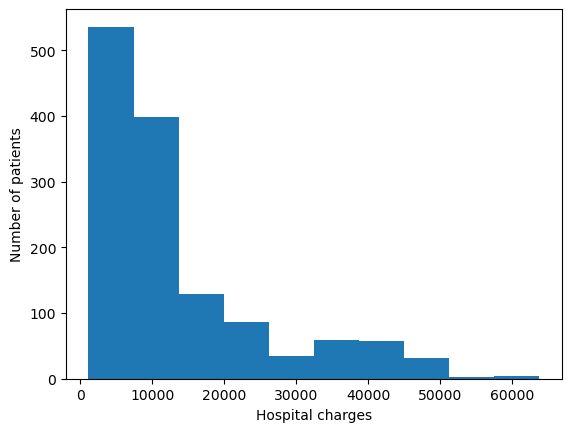

In [20]:
_ = plt.hist(medical['charges'])
_ = plt.xlabel('Hospital charges')
_ = plt.ylabel('Number of patients')

plt.show()

In [30]:
mean_charges = medical['charges'].mean()
mean_std = medical['charges'].std()

print(mean_charges)
print(mean_std)

13270.422265141257
12110.011236693994


Observation: The distribution is skewed to the left which shows that there are more patients clustered towards the lower end of the tail. This means the mean (13,270) is pulled towards the lower tail. Given the skewness of the data, the mean would not be a robust measure. 
The standard deviation suggests high variability but given the skewed data, the standard deviation could be misleading because it assumes symmetry around the mean. 

__Q2:__ The administrator is concerned that the actual average charge has fallen below 12,000, threatening the hospital's operational model. On the assumption that these data represent a random sample of charges, how would you justify that these data allow you to answer that question? And what would be the most appropriate frequentist test, of the ones discussed so far, to apply?

__A:__

If we are assuming that this data represents a random sample of charges, then the sample mean of 13,270 is an unbiased estimator of the true population mean. Also, with CLT, we know that for a larger sample size, the sampling distribution of the mean is approxiately normal, even if the underlying data are skewed. This means, our estimated mean is still a valid observation and can be used to make inference about the population mean. 

We could run a t-test since we are testing a single population mean. The Null Hypothesis could be mean = 12,000 or mean>=12,000 and the alternative hypothesis is mean < 12,000. 

__Q3:__ Given the nature of the administrator's concern, what is the appropriate confidence interval in this case? A ***one-sided*** or ***two-sided*** interval? (Refresh your understanding of this concept on p. 399 of the *AoS*). Calculate the critical value and the relevant 95% confidence interval for the mean, and comment on whether the administrator should be concerned.

__A:__ Since the administrator is worried about the mean charges falling behind 12,000, that is a one-sided interval. I would use a 95% Confidence Interval.

In [46]:
#Critical value for one-sided 95% would be 1.645
n = len(medical['charges'])
#critical z value at 95% CI is 1.645
z = 1.645

moe = z * (mean_std / np.sqrt(n))
print(moe)

544.6059623492973


In [50]:
ci_lower = mean_charges - moe

print(ci_lower)

12725.81630279196


Answer: So the lower bound is 12725.816 and our null hypothesis that the administrator was worried about the mean falling behind 12,000. Since 12726 > 12000, we are 95% confident that the true average hospital charges are above 12,000. 

The administrator then wants to know whether people with insurance really are charged a different amount to those without.

__Q4:__ State the null and alternative hypothesis here. Use the _t_-test for the difference between means, where the pooled standard deviation of the two groups is given by:
\begin{equation}
s_p = \sqrt{\frac{(n_0 - 1)s^2_0 + (n_1 - 1)s^2_1}{n_0 + n_1 - 2}}
\end{equation}

and the *t*-test statistic is then given by:

\begin{equation}
t = \frac{\bar{x}_0 - \bar{x}_1}{s_p \sqrt{1/n_0 + 1/n_1}}.
\end{equation}

(If you need some reminding of the general definition of ***t-statistic***, check out the definition on p. 404 of *AoS*). 

What assumption about the variances of the two groups are we making here?

__A:__ The Null Hypothesis is that the mean charges of insured = mean charges of the non-insured. The Alternative hypothesis is mean charges of insured != mean charges of the non-insured.The assumption is that the variances across these groups are equal. 

__Q5:__ Perform this hypothesis test both manually, using the above formulae, and then using the appropriate function from [scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html#statistical-tests) (hint, you're looking for a function to perform a _t_-test on two independent samples). For the manual approach, calculate the value of the test statistic and then its probability (the p-value). Verify you get the same results from both.

__A:__ 

In [58]:
x0 = medical[medical['insuranceclaim'] == 0]['charges']  # uninsured
x1 = medical[medical['insuranceclaim'] == 1]['charges']  # insured

n0, n1 = len(x0), len(x1)
mean0, mean1 = x0.mean(), x1.mean()
std0, std1 = x0.std(ddof=1), x1.std(ddof=1)

print(n0, n1, mean0, mean1, std0, std1)

555 783 8821.421892306305 16423.928276537677 6446.510126811736 14045.928418802127


In [63]:
#Using the formula above, the pooled standard deviation of the two groups are: 
sp = np.sqrt(((n0 - 1)*std0**2 + (n1 - 1)*std1**2) / (n0 + n1 - 2))

In [65]:
#Calculating t-stat
t_stat = (mean0 - mean1) / (sp * np.sqrt(1/n0 + 1/n1))
print(t_stat)

-11.893299030876715


In [67]:
from scipy import stats

df = n0 + n1 - 2
p_value = 2 * stats.t.sf(np.abs(t_stat), df)

print(p_value)

4.4612302316205886e-31


In [71]:
#Using the scipy.statsa function:
from scipy.stats import ttest_ind_from_stats
ttest_ind_from_stats(mean1=mean0, std1=std0, nobs1=n0,
                     mean2=mean1, std2=std1, nobs2=n1, equal_var=True, alternative='two-sided')

Ttest_indResult(statistic=-11.893299030876719, pvalue=4.4612302316203985e-31)

Congratulations! Hopefully you got the exact same numerical results. This shows that you correctly calculated the numbers by hand. Secondly, you used the correct function and saw that it's much easier to use. All you need to do is pass your data to it.

__Q6:__ Conceptual question: look through the documentation for statistical test functions in scipy.stats. You'll see the above _t_-test for a sample, but can you see an equivalent one for performing a *z*-test from a sample? Comment on your answer.

__A:__ No I cannot see an equivalent z-test in scipy.stats


## Learning outcomes

Having completed this project notebook, you now have good hands-on experience:
* using the central limit theorem to help you apply frequentist techniques to answer questions that pertain to very non-normally distributed data from the real world
* performing inference using such data to answer business questions
* forming a hypothesis and framing the null and alternative hypotheses
* testing this using a _t_-test